# Retail Demand Forecasting

## 5. Baseline Forecasting

This stage establishes benchmark forecasting models against which more advanced forecasting approaches will be evaluated.

Two baseline strategies are considered:

1. Naive Forecast
2. Seasonal Naive Forecast

The baselines provide a reference point for evaluating whether statistical and machine-learning models provide meaningful improvements in predictive accuracy.

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

## 5.1 Load Feature-Engineered Dataset

The feature-engineered dataset created during the previous stage is loaded for chronological baseline evaluation.

In [2]:
DATA_PATH = "outputs/tables/forecasting_features.csv"

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(
    ["date", "store_nbr", "family"]
).reset_index(drop=True)

print(f"Dataset shape: {df.shape}")

Dataset shape: (2950992, 40)


## 5.2 Forecasting Period

The available historical period is examined before defining chronological training, validation, and test periods.

In [3]:
print("Start date:", df["date"].min())
print("End date:", df["date"].max())

print("\nNumber of unique dates:", df["date"].nunique())

print("\nObservations by year:")
print(
    df["date"]
    .dt.year
    .value_counts()
    .sort_index()
)

Start date: 2013-01-29 00:00:00
End date: 2017-08-15 00:00:00

Number of unique dates: 1656

Observations by year:
date
2013    598752
2014    648648
2015    648648
2016    650430
2017    404514
Name: count, dtype: int64


In [4]:
TRAIN_END = "2016-12-31"
VALIDATION_END = "2017-06-30"

In [5]:
train = df[
    df["date"] <= TRAIN_END
].copy()

validation = df[
    (df["date"] > TRAIN_END) &
    (df["date"] <= VALIDATION_END)
].copy()

test = df[
    df["date"] > VALIDATION_END
].copy()

In [6]:
print("Training:", train["date"].min(), "to", train["date"].max())
print("Validation:", validation["date"].min(), "to", validation["date"].max())
print("Test:", test["date"].min(), "to", test["date"].max())

print("\nRows:")
print("Training:", len(train))
print("Validation:", len(validation))
print("Test:", len(test))

Training: 2013-01-29 00:00:00 to 2016-12-31 00:00:00
Validation: 2017-01-01 00:00:00 to 2017-06-30 00:00:00
Test: 2017-07-01 00:00:00 to 2017-08-15 00:00:00

Rows:
Training: 2546478
Validation: 322542
Test: 81972


## 5.3 Naive Forecast

The naive forecasting method uses the most recent observed sales value as the forecast for the next period.

For each store-product family series:

**Forecast(t) = Sales(t − 1)**

This provides a simple benchmark for determining whether more sophisticated models generate meaningful improvements.

In [7]:
validation_naive = validation.copy()

validation_naive["naive_forecast"] = (
    validation_naive
    .groupby(["store_nbr", "family"])["sales"]
    .shift(1)
)

In [8]:
df["naive_forecast"] = (
    df.groupby(["store_nbr", "family"])["sales"]
    .shift(1)
)

In [9]:
validation_naive = df[
    (df["date"] > TRAIN_END) &
    (df["date"] <= VALIDATION_END)
].copy()

## 5.4 Baseline Evaluation Metrics

Forecast performance is evaluated using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)

MAE provides an interpretable measure of average forecast error, while RMSE places greater emphasis on large errors.

Percentage-based error is interpreted carefully because zero or very small sales values can distort MAPE.

In [10]:
def calculate_metrics(actual, predicted):
    mask = actual.notna() & predicted.notna()

    actual = actual[mask]
    predicted = predicted[mask]

    mae = mean_absolute_error(actual, predicted)

    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    non_zero = actual != 0

    mape = (
        np.mean(
            np.abs(
                (actual[non_zero] - predicted[non_zero])
                / actual[non_zero]
            )
        ) * 100
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape
    }

In [11]:
naive_metrics = calculate_metrics(
    validation_naive["sales"],
    validation_naive["naive_forecast"]
)

naive_metrics

{'MAE': 139.24827501920896,
 'RMSE': np.float64(550.0423227455527),
 'MAPE (%)': np.float64(55.81602349331979)}

## 5.5 Seasonal Naive Forecast

The seasonal naive model uses the observed demand from the same store-product family exactly one week earlier.

**Forecast(t) = Sales(t − 7)**

This benchmark explicitly accounts for weekly seasonality and provides a stronger reference point for evaluating advanced forecasting models.

In [12]:
df["seasonal_naive_forecast"] = (
    df.groupby(["store_nbr", "family"])["sales"]
    .shift(7)
)

In [13]:
validation_seasonal = df[
    (df["date"] > TRAIN_END) &
    (df["date"] <= VALIDATION_END)
].copy()

In [14]:
seasonal_naive_metrics = calculate_metrics(
    validation_seasonal["sales"],
    validation_seasonal["seasonal_naive_forecast"]
)

seasonal_naive_metrics

{'MAE': 102.1859462795208,
 'RMSE': np.float64(443.2126606476306),
 'MAPE (%)': np.float64(52.72080879964949)}

## 5.6 Baseline Comparison

The naive and seasonal naive forecasts are compared to determine the predictive value provided by simple temporal structure before introducing advanced forecasting models.

In [15]:
baseline_results = pd.DataFrame(
    [
        {
            "Model": "Naive",
            **naive_metrics
        },
        {
            "Model": "Seasonal Naive",
            **seasonal_naive_metrics
        }
    ]
)

baseline_results

,Model,MAE,RMSE,MAPE (%)
0,Naive,139.25,550.04,55.82
1,Seasonal Naive,102.19,443.21,52.72


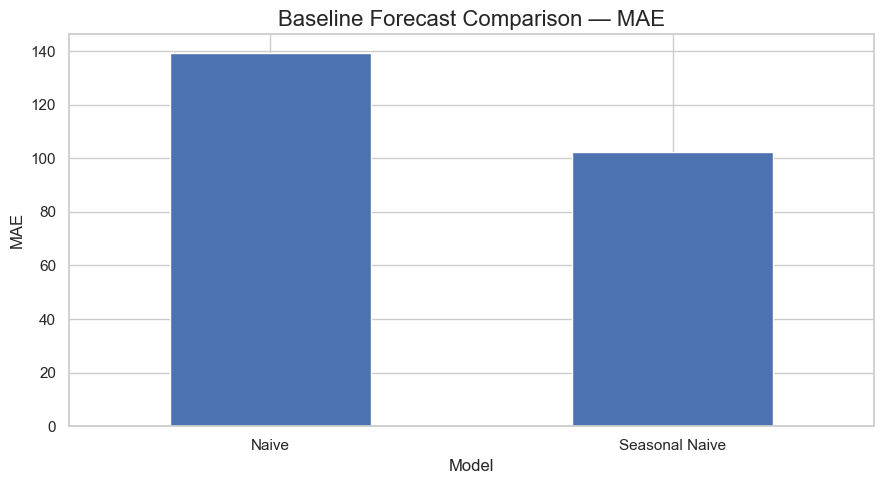

In [16]:
plt.figure(figsize=(9, 5))

baseline_results.set_index("Model")["MAE"].plot(
    kind="bar"
)

plt.title("Baseline Forecast Comparison — MAE", fontsize=16)
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

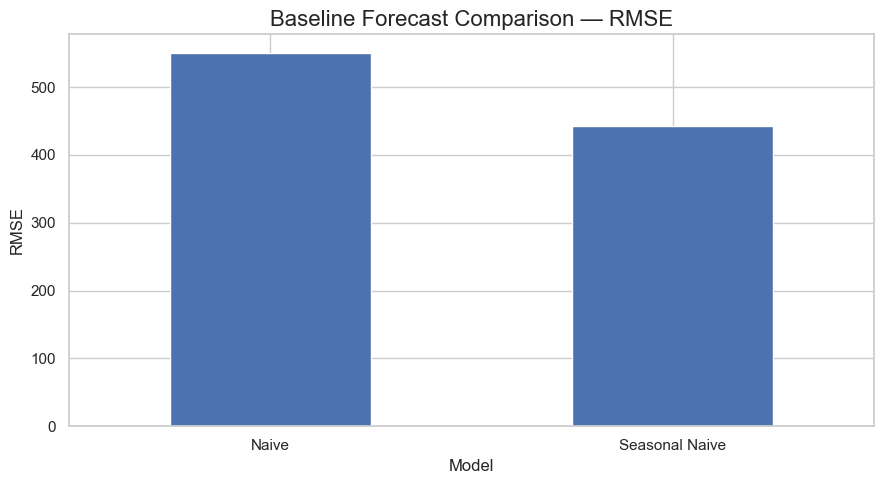

In [17]:
plt.figure(figsize=(9, 5))

baseline_results.set_index("Model")["RMSE"].plot(
    kind="bar"
)

plt.title("Baseline Forecast Comparison — RMSE", fontsize=16)
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5.7 Baseline Forecast Visualization

Forecasts are visualized for a representative store-product family combination to examine how the baseline methods respond to short-term and weekly demand patterns.

In [18]:
sample_store = df["store_nbr"].iloc[0]
sample_family = df["family"].iloc[0]

sample = validation_seasonal[
    (validation_seasonal["store_nbr"] == sample_store) &
    (validation_seasonal["family"] == sample_family)
].copy()

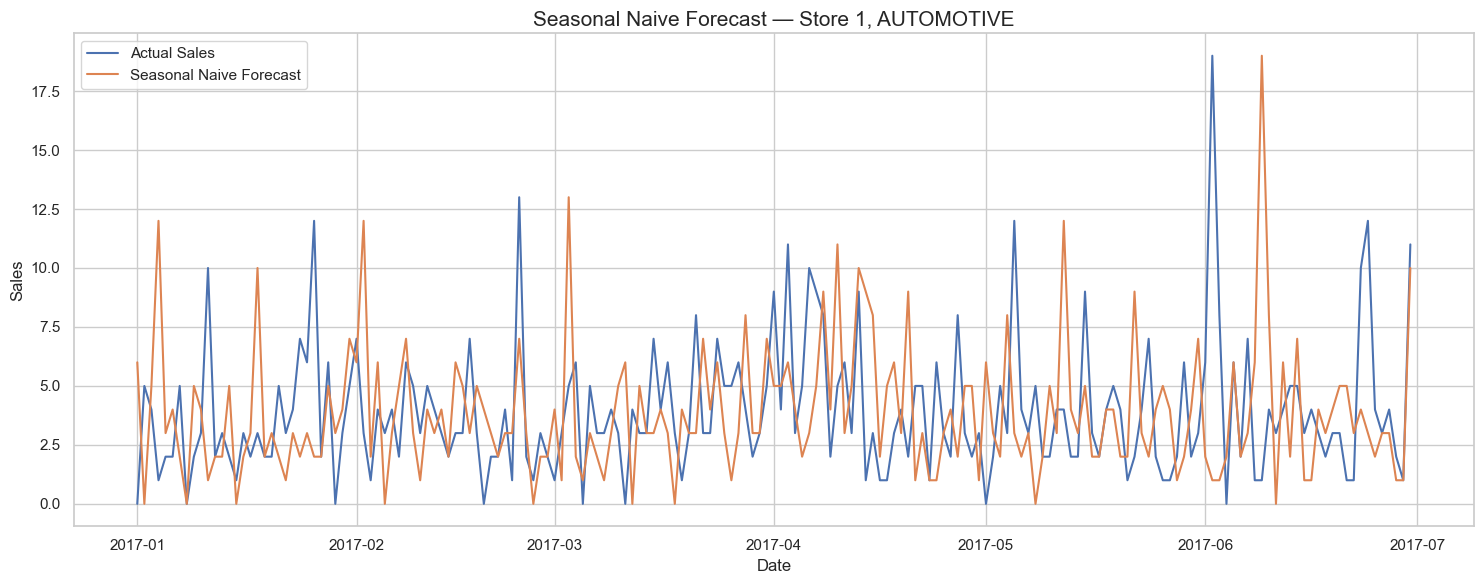

In [19]:
plt.figure(figsize=(15, 6))

plt.plot(
    sample["date"],
    sample["sales"],
    label="Actual Sales"
)

plt.plot(
    sample["date"],
    sample["seasonal_naive_forecast"],
    label="Seasonal Naive Forecast"
)

plt.title(
    f"Seasonal Naive Forecast — Store {sample_store}, {sample_family}",
    fontsize=15
)

plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.tight_layout()
plt.show()

## 5.8 Baseline Performance by Product Family

Forecast errors are examined across product families to identify segments with different levels of predictability.

In [20]:
family_baseline = (
    validation_seasonal
    .groupby("family")
    .apply(
        lambda x: pd.Series(
            calculate_metrics(
                x["sales"],
                x["seasonal_naive_forecast"]
            )
        ),
        include_groups=False
    )
    .reset_index()
)

family_baseline.sort_values(
    "MAE",
    ascending=False
).head(10)

,family,MAE,RMSE,MAPE (%)
12,GROCERY I,979.51,"1,817.38",20.75
3,BEVERAGES,737.92,"1,362.95",21.17
30,PRODUCE,384.07,831.13,16.96
7,CLEANING,315.61,578.63,25.47
8,DAIRY,171.65,320.02,18.63
5,BREAD/BAKERY,98.64,174.90,19.54
25,PERSONAL CARE,96.63,168.53,30.22
28,POULTRY,84.07,188.57,23.76
24,MEATS,74.64,136.55,23.19
18,HOME CARE,70.61,119.17,23.95


In [21]:
family_baseline.sort_values(
    "MAE"
).head(10)

,family,MAE,RMSE,MAPE (%)
4,BOOKS,0.28,0.77,81.84
1,BABY CARE,0.32,0.83,84.99
17,HOME APPLIANCES,0.71,1.23,78.22
14,HARDWARE,1.36,2.07,84.62
2,BEAUTY,3.02,5.03,77.85
23,MAGAZINES,3.70,5.95,80.80
26,PET SUPPLIES,3.83,6.19,67.48
0,AUTOMOTIVE,4.07,5.66,80.14
31,SCHOOL AND OFFICE SUPPLIES,4.22,14.35,106.87
21,LINGERIE,4.59,6.80,95.53


## 5.9 Export Baseline Results

Baseline performance results are saved for comparison with the statistical and machine-learning forecasting models developed in subsequent stages.

In [22]:
os.makedirs(
    "outputs/tables",
    exist_ok=True
)

baseline_results.to_csv(
    "outputs/tables/baseline_results.csv",
    index=False
)

family_baseline.to_csv(
    "outputs/tables/baseline_family_results.csv",
    index=False
)

print("Baseline results exported successfully.")

Baseline results exported successfully.


## 5.10 Baseline Forecasting Summary

The baseline evaluation establishes reference forecasting performance using both recent demand and weekly seasonal demand.

The naive forecast provides a simple short-term benchmark, while the seasonal naive forecast accounts for recurring weekly demand patterns.

These benchmarks will serve as the minimum performance standard for the advanced forecasting models developed in subsequent stages.

An advanced model will only provide meaningful business value if it consistently improves upon these baseline forecasts.